In [1]:
from datetime import datetime

from matplotlib import pyplot as plt

from py_eddy_tracker.dataset.grid import RegularGridDataset

import cartopy.crs as ccrs

from py_eddy_tracker.observations.observation import EddiesObservations

from glob import glob

# Params.:

In [2]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

In [3]:
nyear = 2024
nmonth = 5

# Functions:

In [4]:
def start_axes_map(title):
    fig = plt.figure(figsize=(11, 5))
    ax = fig.add_axes([0.03, 0.03, 0.90, 0.94], projection=ccrs.PlateCarree())

    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")

    # Add coastlines and grid lines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True);     
    gl.top_labels = False; gl.right_labels = False

    return ax

def update_axes(ax, mappable=None):
    ax.grid()
    if mappable:
        plt.colorbar(mappable, cax=ax.figure.add_axes([0.94, 0.05, 0.01, 0.9]))

# Loading data:

In [5]:
from pathlib import Path as PathL

# Get the user's home directory
homedir = PathL.home()
# print(f"Home directory: {homedir}")

In [6]:
indir_miost = str(homedir) + "/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/"
indir_miost_s = indir_miost + 'subset/'


In [7]:
data_paths = sorted(glob(indir_miost_s + "dt_global_allsat_phy_l4_" + str(nyear) + str(nmonth).zfill(2) + "*_sub.nc"))

# Eddy identification:

In [8]:
outdir = "../../data/eddy-tracker_outputs/"

In [9]:
for data_path in data_paths:
    g = RegularGridDataset(data_path, "longitude", "latitude")
    g.add_uv("adt")
    g.bessel_high_filter("adt", 500)
    date = datetime(int(data_path[-15:-11]), int(data_path[-11:-9]),
                    int(data_path[-9:-7]))
    print(date)
    a, c = g.eddy_identification("adt", "u", "v", date , 0.002, shape_error=55)
    a_name = outdir + 'a_MIOST_v2.0.1_' + date.strftime('%Y%m%d')+'.nc'
    c_name = outdir + 'c_MIOST_v2.0.1_' + date.strftime('%Y%m%d')+'.nc'
    a.write_file(filename = a_name)
    c.write_file(filename = c_name)
    

We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240501_sub.nc


2024-05-01 00:00:00


/opt/anaconda3/envs/venv_py-eddy-tracker_05/lib/python3.10/site-packages/numpy/lib/function_base.py:4650: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240502_sub.nc


2024-05-02 00:00:00


No extrema found in contour of 5 pixels in level 0.118000
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240503_sub.nc


...

2024-05-29 00:00:00


We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240530_sub.nc


2024-05-30 00:00:00


We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20240531_sub.nc


2024-05-31 00:00:00


# Checks:

## Checking files generated:

In [10]:
!ls ../../data/eddy-tracker_outputs/*MIOST*01.nc

../../data/eddy-tracker_outputs/a_MIOST_v2.0.1_20240501.nc
../../data/eddy-tracker_outputs/a_MIOST_v2.0.1_20240601.nc
../../data/eddy-tracker_outputs/c_MIOST_v2.0.1_20240501.nc
../../data/eddy-tracker_outputs/c_MIOST_v2.0.1_20240601.nc


## Checking one output file (last day):

In [11]:
a_name

'../../data/eddy-tracker_outputs/a_MIOST_v2.0.1_20240531.nc'

In [12]:
c_name

'../../data/eddy-tracker_outputs/c_MIOST_v2.0.1_20240531.nc'

In [13]:
a = EddiesObservations.load_file(a_name)
c = EddiesObservations.load_file(c_name)

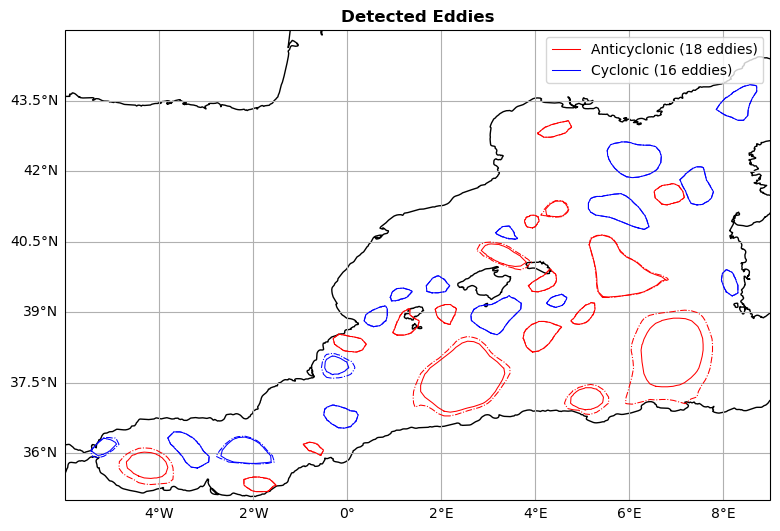

In [14]:
ax = start_axes_map("Detected Eddies")
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)
a.display(
    ax, color="r", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
          )
c.display(
    ax, color="b", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
          )
ax.legend()
update_axes(ax)

#  Code references
https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_eddy_detection.html